# Analyse Training Run

Use this notebook to inspect a training run directory or checkpoint file, review the saved `run_config.yaml`, verify portable relative paths under `resolved`, and plot the training history.

In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.train.load_run import load_history, load_run_config, resolve_run_and_checkpoint

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)




In [108]:
# RUN_INPUT = "src/models/saved_weights/chinese_single_label_mel_cnn_ft_irmas"
# RUN_INPUT = "src/models/saved_weights/irmas/irmas_single_label_mel_densenet_121"
RUN_INPUT = "src/models/saved_weights/irmas/irmas_single_label_mel_cnn"

PREFERRED_WEIGHT = "best_val.pt"
PROJECT_ROOT_HINT: str | None = None


In [ ]:
from src.train.load_run import resolve_saved_paths


advisor: list[str] = []
resolved = None
run_cfg: dict = {}
history_df = pd.DataFrame()
history_source = "none"
resolved_paths_df = pd.DataFrame()
classes_df = pd.DataFrame()

try:
    resolved = resolve_run_and_checkpoint(RUN_INPUT, PREFERRED_WEIGHT, PROJECT_ROOT_HINT)
    run_cfg = load_run_config(resolved["run_cfg_path"])
    history_df, history_source, notes = load_history(resolved["history_csv_path"], resolved["ckpt_path"])
    advisor.extend(notes)

    if resolved is not None and run_cfg:
        resolved_paths_df = resolve_saved_paths(run_cfg, resolved["project_root"])
        classes = run_cfg.get("classes", [])
        if classes:
            classes_df = pd.DataFrame({"class_name": classes})
except Exception as exc:
    advisor.append(str(exc))

if resolved is None:
    summary = {
        "status": "error",
        "run_dir": "n/a",
        "checkpoint": "n/a",
        "history_source": history_source,
        "history_rows": 0,
    }
else:
    summary = {
        "status": "ok" if not history_df.empty else "warning",
        "project_root": str(resolved["project_root"]),
        "resolved_input": str(resolved["resolved_input"]),
        "run_dir": str(resolved["run_dir"]),
        "checkpoint": str(resolved["ckpt_path"]) if resolved["ckpt_path"] else "not found",
        "history_source": history_source,
        "history_rows": int(len(history_df)),
        "task_mode": run_cfg.get("task_mode", "unknown"),
        "feature_mode": run_cfg.get("feature_mode", "unknown"),
        "dataset": run_cfg.get("dataset", "unknown"),
        "experiment_name": run_cfg.get("experiment_name", "unknown"),
        "backbone": ((run_cfg.get("model") or {}).get("backbone", "unknown")),
        "num_classes": int(len(run_cfg.get("classes", []))),
    }

display(pd.DataFrame([summary]).T.rename(columns={0: "value"}))

if not resolved_paths_df.empty:
    display(resolved_paths_df)

if not classes_df.empty:
    display(classes_df)


,value
status,ok
project_root,/Users/hughsignoriello/Developer/ml-based-anal...
resolved_input,/Users/hughsignoriello/Developer/ml-based-anal...
run_dir,/Users/hughsignoriello/Developer/ml-based-anal...
checkpoint,/Users/hughsignoriello/Developer/ml-based-anal...
history_source,history.csv
history_rows,50
task_mode,single_label
feature_mode,mel
dataset,irmas


,key,stored,absolute,exists
0,train_config,src/configs/training/irmas/single_label_mel.yaml,/Users/hughsignoriello/Developer/ml-based-anal...,False
1,audio_config,src/configs/audio_params.yaml,/Users/hughsignoriello/Developer/ml-based-anal...,True
2,labels_config,src/configs/labels.yaml,/Users/hughsignoriello/Developer/ml-based-anal...,True
3,primary_manifest,data/processed/irmas_train_mels.csv,/Users/hughsignoriello/Developer/ml-based-anal...,True
4,cqt_manifest,,,False
5,run_dir,src/models/saved_weights/irmas/irmas_single_la...,/Users/hughsignoriello/Developer/ml-based-anal...,True
6,resume_checkpoint,src/models/saved_weights/irmas/irmas_single_la...,/Users/hughsignoriello/Developer/ml-based-anal...,True


,class_name
0,cel
1,cla
2,flu
3,gac
4,gel
5,org
6,pia
7,sax
8,tru
9,vio


In [110]:
if advisor:
    print("Troubleshooting notes:")
    for msg in advisor:
        print(f"- {msg}")

if history_df.empty:
    print("\nNo plottable training history available yet.")
    print("Fix checklist:")
    print("1) Confirm RUN_INPUT points to the correct run directory or .pt checkpoint.")
    print("2) Prefer a run with history.csv (produced after training completes).")
    print("3) If using checkpoint fallback, ensure torch imports in this kernel.")
    print("4) If a resolved path is relative, it is interpreted from the detected project root shown above.")


In [111]:
diagnostics = {}

if not history_df.empty and "epoch" not in history_df.columns:
    history_df = history_df.copy()
    history_df.insert(0, "epoch", range(1, len(history_df) + 1))

if not history_df.empty and "val_loss" in history_df.columns:
    best_idx = int(history_df["val_loss"].idxmin())
    best_row = history_df.loc[best_idx]
    diagnostics["best_val_loss"] = float(best_row["val_loss"])
    diagnostics["best_val_loss_epoch"] = int(best_row["epoch"])

if not history_df.empty:
    for metric in ("val_acc", "val_accuracy"):
        if metric in history_df.columns:
            idx = int(history_df[metric].idxmax())
            diagnostics[f"best_{metric}"] = float(history_df.loc[idx, metric])
            diagnostics[f"best_{metric}_epoch"] = int(history_df.loc[idx, "epoch"])

display(
    pd.DataFrame([diagnostics]).T.rename(columns={0: "value"})
    if diagnostics
    else pd.DataFrame({"info": ["No diagnostics available"]})
)

if not history_df.empty:
    display(history_df.tail(10).reset_index(drop=True))


,value
best_val_loss,1.024717
best_val_loss_epoch,48.000000
best_val_acc,0.644828
best_val_acc_epoch,38.000000


,epoch,train_acc,train_loss,train_macro_f1,train_micro_f1,val_acc,val_loss,val_macro_f1,val_micro_f1
0,41,0.642318,1.015558,0.628328,0.642318,0.626724,1.057900,0.612015,0.626724
1,42,0.645551,1.006980,0.630703,0.645551,0.630172,1.042206,0.613381,0.630172
2,43,0.648567,1.005980,0.634976,0.648567,0.633621,1.039577,0.618202,0.633621
3,44,0.651153,1.010919,0.637975,0.651153,0.626724,1.043757,0.613237,0.626724
4,45,0.649644,1.003965,0.635960,0.649644,0.642241,1.037095,0.628812,0.642241
5,46,0.646628,1.011344,0.632744,0.646628,0.638793,1.032274,0.624418,0.638793
6,47,0.653954,0.996382,0.638930,0.653954,0.631034,1.045852,0.618855,0.631034
7,48,0.650937,1.006687,0.637020,0.650937,0.642241,1.024717,0.629426,0.642241
8,49,0.658479,0.992397,0.644954,0.658479,0.641379,1.030387,0.630286,0.641379
9,50,0.653523,0.998066,0.640301,0.653523,0.634483,1.054256,0.618586,0.634483


In [ ]:
from src.train.load_run import metric_pairs


pairs = metric_pairs(history_df.columns) if not history_df.empty else []
pairs


[('loss', 'train_loss', 'val_loss'), ('acc', 'train_acc', 'val_acc')]

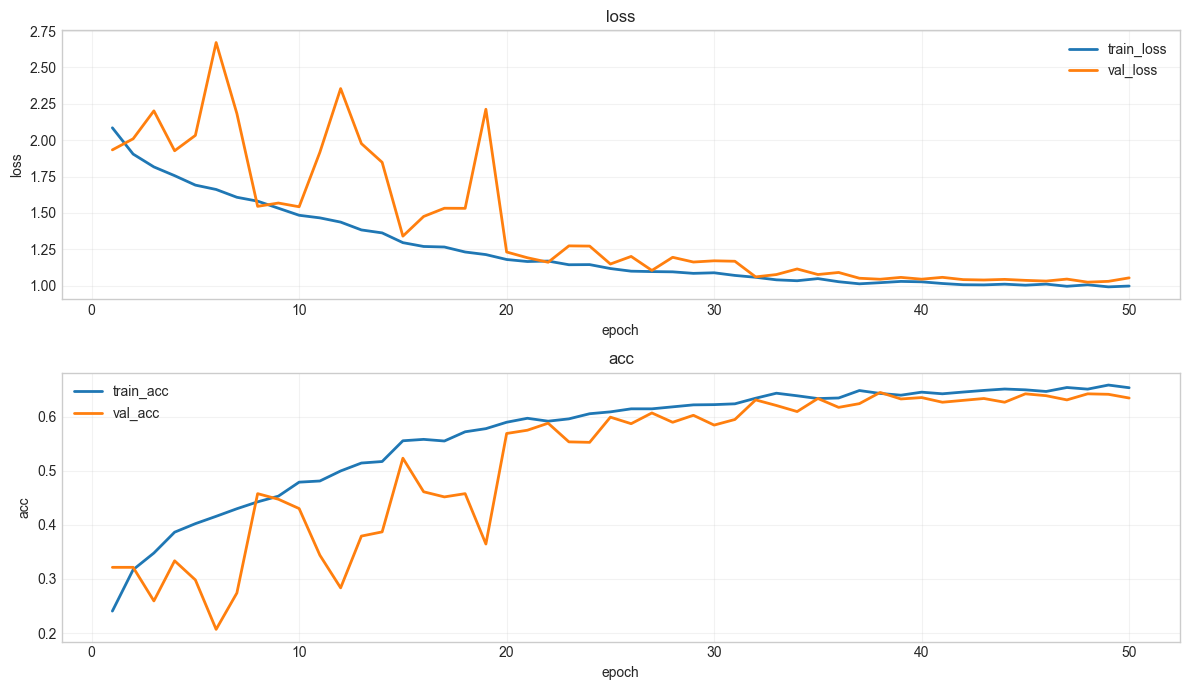

In [113]:
if history_df.empty:
    print("Skipping plots: history unavailable.")
elif not pairs:
    print("Skipping plots: no train_/val_ metric pairs in history.")
else:
    n = len(pairs)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, max(3.5 * n, 4)), squeeze=False)

    for i, (base, train_col, val_col) in enumerate(pairs):
        ax = axes[i, 0]
        ax.plot(history_df["epoch"], history_df[train_col], label=train_col, linewidth=2)
        ax.plot(history_df["epoch"], history_df[val_col], label=val_col, linewidth=2)
        ax.set_title(base)
        ax.set_xlabel("epoch")
        ax.set_ylabel(base)
        ax.legend(loc="best")
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()
